# Test-set performance by clinical class

Per-patient metrics of one finetuning run, as written by `eval_finetune.py` to `Output_cmp/<run>_metrics.csv`,
split by the dataset's malocclusion / overbite / overjet labels.

In [ ]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Works whether the kernel starts in src/ or at the project root.
sys.path.insert(0, str(next(d for d in (Path.cwd(), Path.cwd() / "src", Path.cwd().parent)
                            if (d / "s1_oral_scan.py").is_file())))
from s1_oral_scan import CMP_DIR, DATASET_DIR, RUNS_DIR


In [ ]:
# version_13-15 share the current test split; version_0-4 and version_12 were scored on older ones.
RUN = "version_15"

RUN_DIR = RUNS_DIR / "lightning_logs" / RUN
LABEL_DIR = DATASET_DIR.parent

METRICS = {
    "rotation [deg]": "rotation [°]",
    "translation [mm]": "translation [mm]",
    "point cloud [mm]": "point cloud [mm]",
    "collision [mm]": "collision [mm]",
}
TRAITS = ["Malocclusion", "Overbite", "Overjet"]

## Load the run

The CSV must hold exactly the `test` patients of the run's own `splits.json`, otherwise the numbers are not a held-out evaluation.

In [ ]:
df = pd.read_csv(CMP_DIR / f"{RUN}_metrics.csv", header=[0, 1], index_col=0, dtype={0: str})["finetuned"]

test_ids = json.loads((RUN_DIR / "splits.json").read_text())["test"]
assert set(df.index) == set(test_ids), "the CSV does not hold this run's test split"
len(df)

90

In [ ]:
def read_labels(trait):
    text = (LABEL_DIR / f"{trait}.txt").read_text()
    return {
        patient: cls
        for cls, ids in re.findall(r'"([^"]+)"\s*:\s*\{([^}]*)\}', text)
        for patient in re.findall(r"\d{4}", ids)
    }


for trait in TRAITS:
    df[trait] = df.index.map(read_labels(trait))

df[TRAITS].isna().sum()  # Overbite.txt misses 0736 and 0818

Malocclusion    0
Overbite        1
Overjet         0
dtype: int64

## Overall distribution

In [ ]:
df[list(METRICS)].describe().round(3)

,rotation [deg],translation [mm],point cloud [mm],collision [mm]
count,90.000,90.000,90.000,90.000
mean,7.582,1.495,1.300,0.193
std,2.709,0.536,0.654,0.109
min,3.412,0.672,0.500,0.033
25%,5.779,1.102,0.835,0.109
50%,7.362,1.442,1.125,0.162
75%,9.027,1.788,1.575,0.258
max,19.877,3.557,3.990,0.477


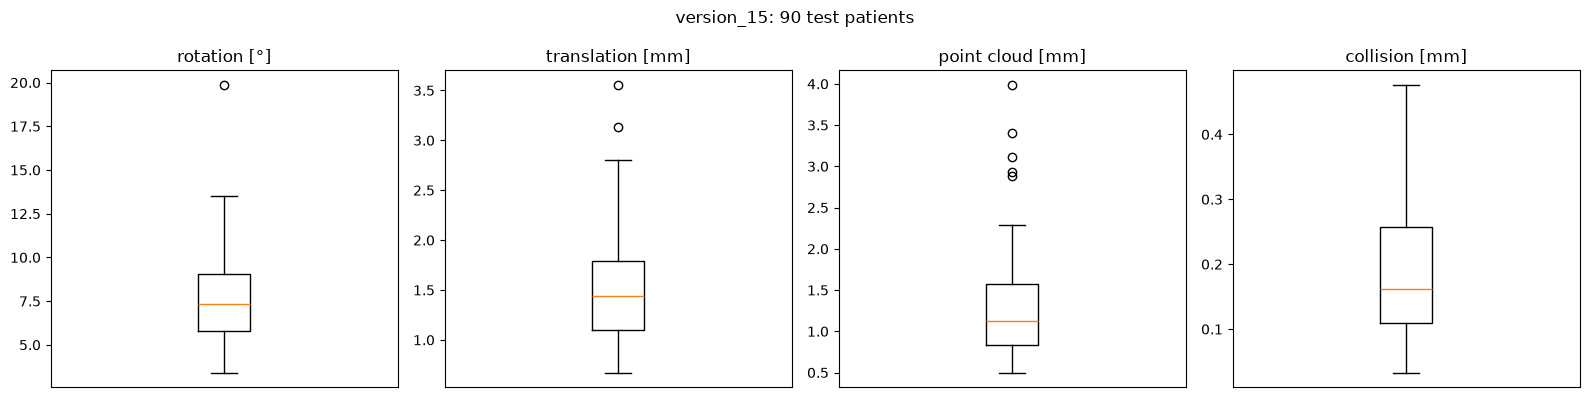

In [ ]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 4))
for ax, (col, label) in zip(axes, METRICS.items()):
    ax.boxplot(df[col])
    ax.set_title(label)
    ax.set_xticks([])
fig.suptitle(f"{RUN}: {len(df)} test patients")
fig.tight_layout()

In [ ]:
def plot_by_class(trait):
    rng = np.random.default_rng(0)
    classes = df[trait].value_counts().index
    fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 4.5))
    for ax, (col, label) in zip(axes, METRICS.items()):
        groups = [df.loc[df[trait] == cls, col] for cls in classes]
        ax.boxplot(groups, tick_labels=[f"{cls} ({len(g)})" for cls, g in zip(classes, groups)],
                   showfliers=False)
        for i, values in enumerate(groups, start=1):
            ax.scatter(rng.normal(i, 0.06, len(values)), values, s=8, alpha=0.5, color="C0")
        ax.axhline(df[col].median(), color="red", ls="--", lw=1)
        ax.set_title(label)
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    fig.suptitle(trait)
    fig.tight_layout()
    plt.show()

In [ ]:
def class_table(trait):
    labelled = df.dropna(subset=[trait])
    rows = []
    for cls, inside in labelled.groupby(trait):
        rest = labelled[labelled[trait] != cls]
        for col in METRICS:
            rows.append({
                "class": cls,
                "n": len(inside),
                "metric": col,
                "Δ vs rest": inside[col].median() - rest[col].median(),
                "q": stats.mannwhitneyu(inside[col], rest[col]).pvalue,
            })
    table = pd.DataFrame(rows)
    table["q"] = stats.false_discovery_control(table["q"])
    wide = table.pivot(index=["class", "n"], columns="metric", values=["Δ vs rest", "q"])
    return wide.reindex(columns=list(METRICS), level="metric").round(3)

### Malocclusion

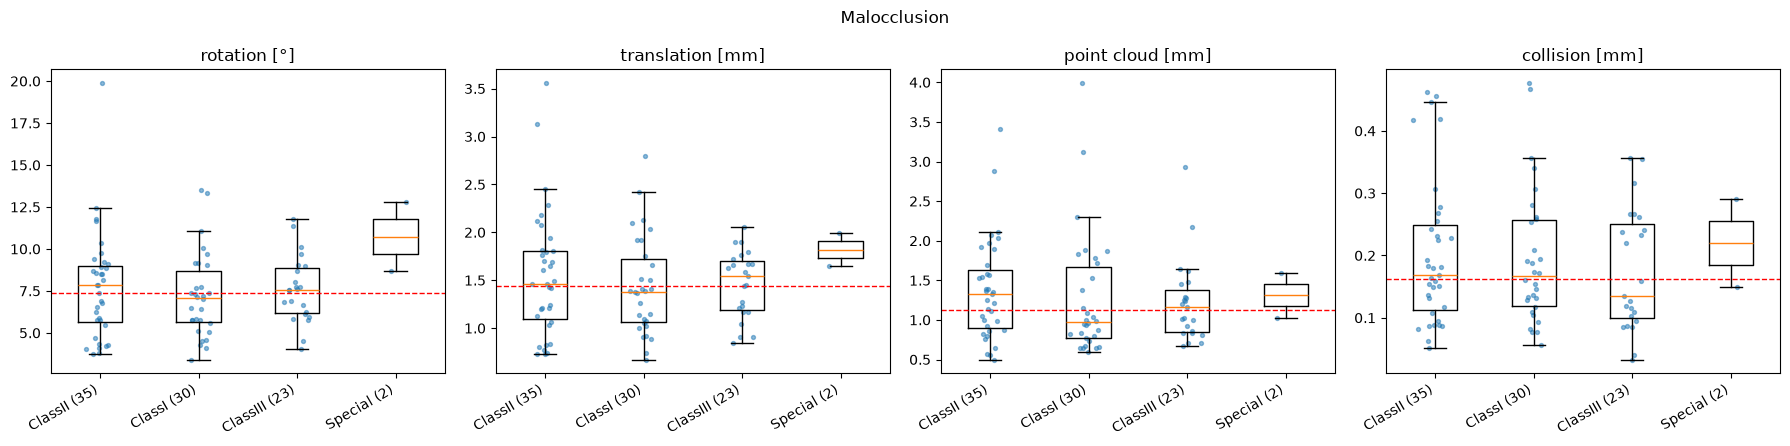

Δ vs rest                                                   \
metric      rotation [deg] translation [mm] point cloud [mm] collision [mm]   
class    n                                                                    
ClassI   30         -0.578           -0.134           -0.250          0.004   
ClassII  35          0.481            0.057            0.299          0.010   
ClassIII 23          0.208            0.119            0.055         -0.034   
Special  2           3.376            0.388            0.188          0.058   

                         q                                                   
metric      rotation [deg] translation [mm] point cloud [mm] collision [mm]  
class    n                                                                   
ClassI   30          0.930             0.93             0.93           0.94  
ClassII  35          0.947             0.94             0.93           0.94  
ClassIII 23          0.940             0.94             0.94           0.94  
Special  2           0.930             0.93             0.94           0.94

In [ ]:
plot_by_class("Malocclusion")
class_table("Malocclusion")

### Overbite

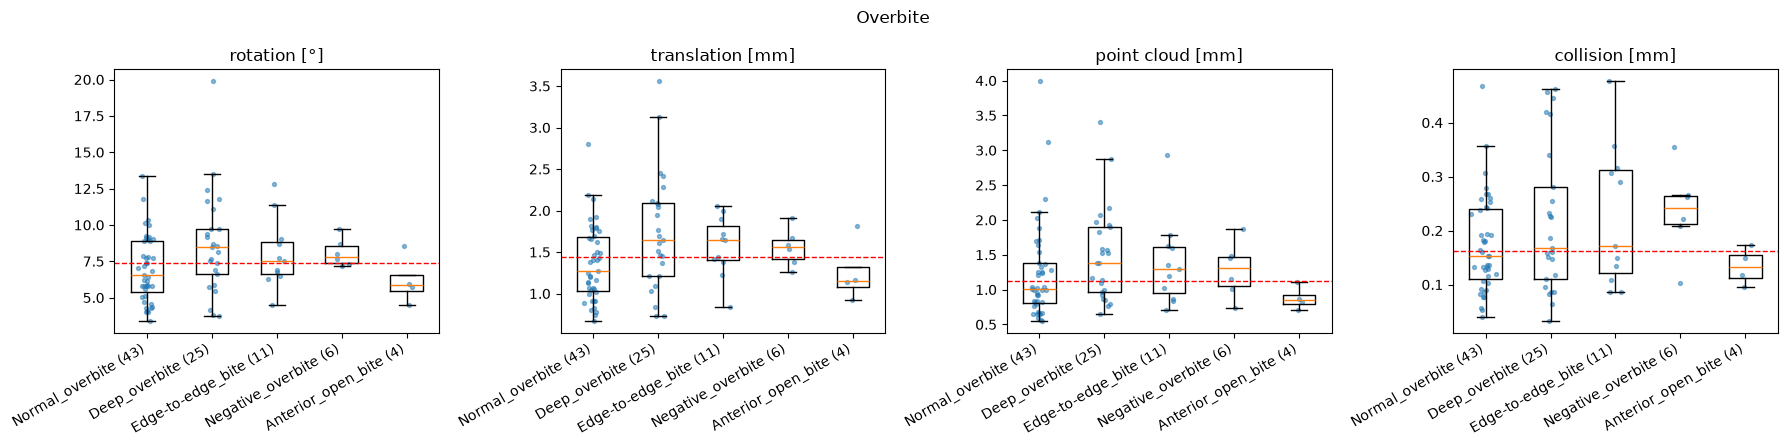

Δ vs rest                                    \
metric                rotation [deg] translation [mm] point cloud [mm]   
class              n                                                     
Anterior_open_bite 4          -1.527           -0.309           -0.318   
Deep_overbite      25          1.392            0.244            0.354   
Edge-to-edge_bite  11          0.184            0.207            0.197   
Negative_overbite  6           0.459            0.125            0.196   
Normal_overbite    43         -1.168           -0.325           -0.242   

                                                  q                   \
metric                collision [mm] rotation [deg] translation [mm]   
class              n                                                   
Anterior_open_bite 4          -0.035          0.482            0.533   
Deep_overbite      25          0.006          0.234            0.234   
Edge-to-edge_bite  11          0.010          0.598            0.533   
Negative_overbite  6           0.081          0.533            0.598   
Normal_overbite    43         -0.019          0.234            0.234   

                                                       
metric                point cloud [mm] collision [mm]  
class              n                                   
Anterior_open_bite 4             0.352          0.533  
Deep_overbite      25            0.234          0.598  
Edge-to-edge_bite  11            0.598          0.533  
Negative_overbite  6             0.696          0.417  
Normal_overbite    43            0.234          0.417

In [ ]:
plot_by_class("Overbite")
class_table("Overbite")

### Overjet

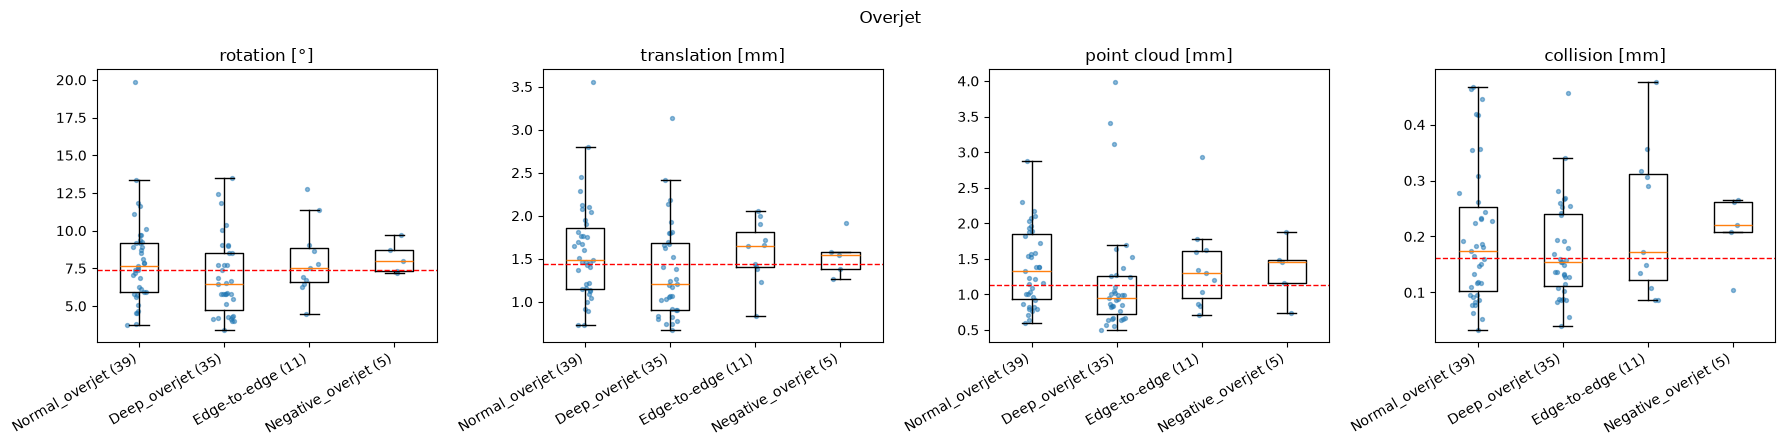

Δ vs rest                                    \
metric              rotation [deg] translation [mm] point cloud [mm]   
class            n                                                     
Deep_overjet     35         -1.192           -0.294           -0.376   
Edge-to-edge     11          0.184            0.218            0.206   
Negative_overjet 5           0.654            0.103            0.362   
Normal_overjet   39          0.711            0.104            0.322   

                                                q                   \
metric              collision [mm] rotation [deg] translation [mm]   
class            n                                                   
Deep_overjet     35         -0.027          0.167            0.167   
Edge-to-edge     11          0.012          0.613            0.581   
Negative_overjet 5           0.061          0.581            0.727   
Normal_overjet   39          0.015          0.581            0.581   

                                                     
metric              point cloud [mm] collision [mm]  
class            n                                   
Deep_overjet     35            0.067          0.581  
Edge-to-edge     11            0.593          0.581  
Negative_overjet 5             0.640          0.581  
Normal_overjet   39            0.170          0.942

In [ ]:
plot_by_class("Overjet")
class_table("Overjet")